# Introductory task for Applied Artificial Intelligence Lab

## Relevant information

I am an ERASMUS student, so I am only here for this semester. 

During my last semester in France, I passed a class about data analysis where I learned how to process and clean the data. I also learned about PCA, CCA, FCA and clustering algorithms.

Another class was about regression algorithms, where I applied linear regression, logistic regression with regularization such as Lasso and Ridge.

In [115]:
import os
import pandas as pd
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
from PIL import Image
from tqdm import tqdm
import re
import csv
import matplotlib.pyplot as plt
import torch

# Rainy or Sunny

In [116]:
weather_to_idx = {"rainy": 0, "sunny": 1}

class WeatherDataset(Dataset):
    def __init__(self, annotations_file, img_dir, transform=None):
        self.img_labels = pd.read_csv(annotations_file)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])
        image = Image.open(img_path).convert("RGB")
        label_name = self.img_labels.iloc[idx, 1]
        label = weather_to_idx[label_name]
        if self.transform:
            image = self.transform(image)
        return image, label

In [117]:
img_path = "data/all_except_marked"

data = []
for filename in os.listdir(img_path):
    if filename.lower().endswith(('.png')):
        match = re.match(r"image_\d*(\D+)_(\w+)\.\w+", filename)
        if match:
            style = match.group(1)   # "realistic"
            weather = match.group(2) # "rainy"
            data.append([filename, weather, style])
        else:
            print(f"Nom inattendu : {filename}")
            
csv_path = os.path.join(img_path, "image_metadata.csv")
with open(csv_path, "w", newline="") as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(["filename", "weather", "style"])
    writer.writerows(data)

In [118]:
first_dataset = WeatherDataset(annotations_file=csv_path, img_dir=img_path)

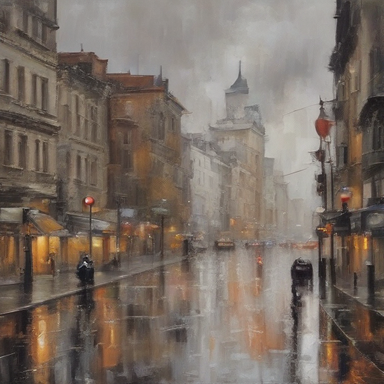

In [119]:
image, label = first_dataset[0]
image

In [120]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

first_dataset = WeatherDataset(annotations_file=csv_path, img_dir=img_path, transform=transform)

total_size = len(first_dataset)

train_size = int(0.8 * total_size)
val_size = int(0.1 * total_size)
test_size = total_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    first_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

In [121]:
len(first_dataset), len(train_dataset), len(val_dataset), len(test_dataset)

(160, 128, 16, 16)

In [122]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [123]:
class WeatherClassifier(nn.Module):
    def __init__(self, num_classes=2):
        super(WeatherClassifier, self).__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64 * 32 * 32, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        return self.net(x)

In [124]:
model = WeatherClassifier(num_classes=2)
print(str(model)[:500])

WeatherClassifier(
  (net): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=65536, out_features=128, bias=True)
    (


In [125]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [126]:
num_epochs = 15
train_losses, val_losses = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in tqdm(train_loader, desc='Training'):
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * labels.size(0)
    
    train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(train_loss)

    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc='Validation'):
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * labels.size(0)
    
    val_loss = running_loss / len(val_loader.dataset)
    val_losses.append(val_loss)
    print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

Validation: 100%|██████████| 1/1 [00:00<00:00,  4.58it/s]


Epoch 1/15, Train Loss: 1.5966, Val Loss: 1.2405


Validation: 100%|██████████| 1/1 [00:00<00:00,  4.34it/s]


Epoch 2/15, Train Loss: 0.7229, Val Loss: 0.5515


Validation: 100%|██████████| 1/1 [00:00<00:00,  4.48it/s]


...

Epoch 13/15, Train Loss: 0.0001, Val Loss: 0.0012


Validation: 100%|██████████| 1/1 [00:00<00:00,  4.58it/s]


Epoch 14/15, Train Loss: 0.0001, Val Loss: 0.0014


Validation: 100%|██████████| 1/1 [00:00<00:00,  3.91it/s]

Epoch 15/15, Train Loss: 0.0001, Val Loss: 0.0006


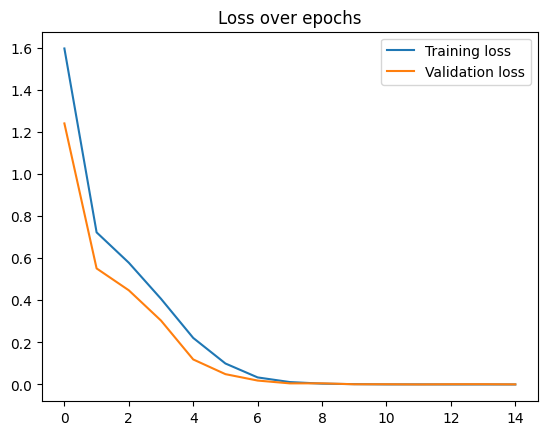

In [128]:
plt.plot(train_losses, label='Training loss')
plt.plot(val_losses, label='Validation loss')
plt.legend()
plt.title("Loss over epochs")
plt.show()